# Compute input datasets for sedflux generation from model output

Generate a set of files for each of the following groups:

- scalar: ['POC_FLUX_IN', 'TEMP', 'KVMIX']
- vector: ['UVEL', 'VVEL']

Steps:
1. Produce files on a set of source grids
1. Optionally generate on a set of destination grids


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import os
import shutil
from glob import glob

from itertools import product

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

import esmlab
import esmlab_regrid

import pop_tools

import util

In [3]:
clobber = False
serial = True

## Build and test horizontal regridding

### Generate SCRIP grid files for each of the supported grids.

Ideally, a regridding workflow would support this in situ.

In [4]:
tst_grid = "POP_gx3v7"
src_grid = "POP_gx1v7"
dst_grid = "MOM_tx2_3v2"

In [5]:
grids = {}
for grid_name in [tst_grid, src_grid, dst_grid]:
    if grid_name in util.POP_grids:
        grids[grid_name] = pop_tools.get_grid(grid_name)
    elif grid_name in ["MOM_tx0.66v1", "MOM_tx2_3v2"]:
        grids[grid_name] = util.get_MOM_grid(grid_name)
        grids[grid_name] = grids[grid_name]

grids

{'POP_gx3v7': <xarray.Dataset>
 Dimensions:      (nlat: 116, nlon: 100, z_t: 60, z_w: 60, z_w_bot: 60)
 Coordinates:
   * z_t          (z_t) float64 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
   * z_w          (z_w) float64 0.0 1e+03 2e+03 3e+03 ... 4.75e+05 5e+05 5.25e+05
   * z_w_bot      (z_w_bot) float64 1e+03 2e+03 3e+03 ... 5e+05 5.25e+05 5.5e+05
 Dimensions without coordinates: nlat, nlon
 Data variables: (12/13)
     TLAT         (nlat, nlon) float64 -71.81 -71.81 -71.81 ... 68.36 68.26 68.21
     TLONG        (nlat, nlon) float64 323.3 326.9 330.5 ... 317.8 319.3 320.8
     ULAT         (nlat, nlon) float64 -78.73 -78.73 -78.73 ... 68.49 68.42 68.4
     ULONG        (nlat, nlon) float64 325.1 328.7 332.3 ... 318.7 320.1 321.5
     DXT          (nlat, nlon) float64 6.842e+06 6.828e+06 ... 6.129e+06
     DYT          (nlat, nlon) float64 1.686e+07 1.686e+07 ... 4.524e+06
     ...           ...
     DYU          (nlat, nlon) float64 1.686e+07 1.686e+07 ... 1.069e+07
     TAREA

### Construct weight file names and ensure they are present

`esmlab_regrid` should support generating weight files, but I am getting and ESMF error about PIO not being available. Probably this requires some `module loads` before launching...but that's not acceptable if that's the case, there should be no dependencies outside of the `conda` environment.

As a workaround, I wrote [esmf_gen_weights_pop2pop.pbs](esmf_gen_weights_pop2pop.pbs) and run this on the batch nodes.

In [6]:
method = 'conservative'
get_key = lambda src, dst: f'{src}_to_{dst}_{method}'    

weight_files = {}
for src, dst in product(grids.keys(), grids.keys()): 
    if src == dst: continue
    if src.startswith("MOM"): continue
    if src == "POP_gx3v7" and dst.startswith("MOM"): continue
    key = get_key(src, dst)
    value = util.file_name_weight(src, dst, method)
    weight_files[key] = value
    
missing = {k: f for k, f in weight_files.items() if not os.path.exists(f)}
if missing:
    missing_some = True
    print(f'missing weight files:\n{list(missing.keys())}\n\nrun the following:\nqsub < esmf_gen_weights_POP_to_POP.pbs\n')
else:
    print('all weight files are present')

all weight files are present


### Construct dictionary of horizontal regridding operators

In [7]:
regrid_operator = {}
key = get_key(src_grid, dst_grid)
regrid_operator[key] = esmlab_regrid.regridder(
    name_grid_src=src_grid, 
    name_grid_dst=dst_grid, 
    method=method, 
    overwrite_existing=False
)

"Test" regridding with `TAREA` field from the grid. Here I am just aiming to pass a sniff test: does the remapped field look right.

What's a better way to test this? The differing land-mask will mean integrals don't match....


Text(0.5, 1.0, 'To grid: MOM_tx2_3v2')

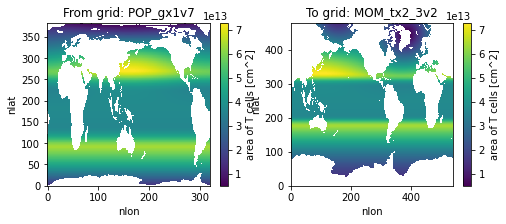

In [8]:
key = get_key(src_grid, dst_grid)

da_src = grids[src_grid].TAREA.where(grids[src_grid].KMT > 0)

da_dst = regrid_operator[key](
    da_src,
    renormalize=True, 
    apply_mask=True
)

fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(1, 2, 1)
da_src.plot()
ax.set_title(f'From grid: {src_grid}')
ax = fig.add_subplot(1, 2, 2)
da_dst.plot()
ax.set_title(f'To grid: {dst_grid}')

### Define vertical interpolation

Generate pseudo-data for each grid, a DataArray with 0:km-1 in each column

In [9]:
if src_grid.startswith("POP"):
    nk, nj, ni = len(grids[src_grid].z_t), len(grids[src_grid].nlat), len(grids[src_grid].nlon)
    k = xr.DataArray(np.arange(0, nk), dims=('z_t'), coords={'z_t': grids[src_grid].z_t})
    ones = xr.DataArray(
        np.ones((nk, nj, ni)), 
        dims=('z_t', 'nlat', 'nlon'), 
        coords={'z_t': grids[src_grid].z_t}
    )
    
    da_test_src = k * ones 

Test vertical remappiong function

In [10]:
key = f"{src_grid}_to_{dst_grid}"

if not dst_grid.startswith("MOM"):
    da_dst = util.remap_z_t(
        da_test_src, 
        src_grid,
        dst_grid,
    )

    nk_src, nk_dst = len(da_test_src.z_t), len(da_dst.z_t)
    if nk_src < nk_dst:
        assert (da_test_src[:, 0, 0] == da_dst[:nk_src, 0, 0]).all()
        assert (da_test_src[-1, 0, 0] == da_dst[-(nk_dst-nk_src):, 0, 0]).all()        

    elif nk_src > nk_dst:
        assert (da_test_src[:nk_dst, 0, 0] == da_dst[:, 0, 0]).all()        

    else:
        assert (da_dst[:, 0, 0] == da_test_src[:, 0, 0]).all()
else:
    da_dst = util.reintegrate_z_t_to_MOM(da_test_src, grids[src_grid])
    print(da_dst)

<xarray.DataArray (z_t: 103, nlat: 384, nlon: 320)>
array([[[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
...
        [19

Define a fill procedure based on `pop_tools`. 

First, define a function to generate a 3D mask.

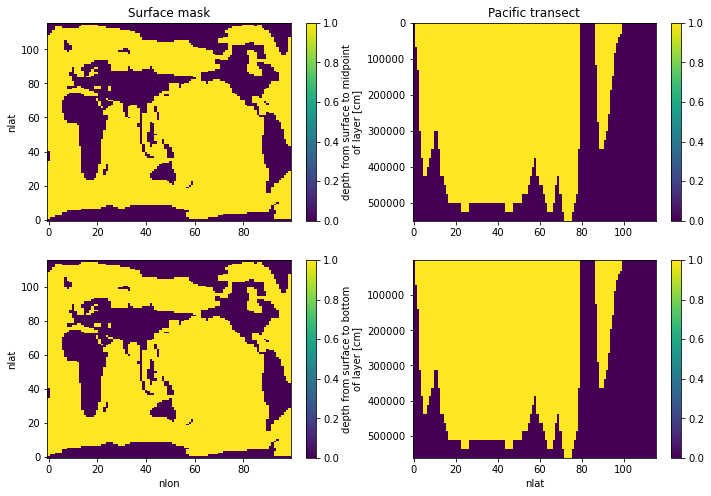

In [11]:
def get_mask_zt(ds_pop):
    required_vars = ['z_t', 'KMT']
    missing_vars = set(required_vars) - set(ds_pop.variables)
    if missing_vars:
        raise ValueError(f'missing required vars:\n {missing_vars}')
    
    nk, nj, ni = len(ds_pop.z_t), len(ds_pop.nlat), len(ds_pop.nlon)

    # make 3D array of 0:km
    zero_to_km = xr.DataArray(np.arange(0, nk), dims=('z_t'))
    ONES_3d = xr.DataArray(np.ones((nk, nj, ni)), dims=('z_t', 'nlat', 'nlon'))
    ZERO_TO_KM = (zero_to_km * ONES_3d)

    # mask out cells where k is below KMT
    MASK = ZERO_TO_KM.where(ZERO_TO_KM < ds_pop.KMT)
    MASK = xr.where(MASK.notnull(), True, False)

    return MASK.assign_coords({'z_t': ds_pop.z_t})

def get_mask_zw(ds_pop):
    required_vars = ['z_w_bot', 'KMT']
    missing_vars = set(required_vars) - set(ds_pop.variables)
    if missing_vars:
        raise ValueError(f'missing required vars:\n {missing_vars}')
    
    nk, nj, ni = len(ds_pop.z_w_bot), len(ds_pop.nlat), len(ds_pop.nlon)

    # make 3D array of 0:km
    zero_to_km = xr.DataArray(np.arange(0, nk), dims=('z_w_bot'))
    ONES_3d = xr.DataArray(np.ones((nk, nj, ni)), dims=('z_w_bot', 'nlat', 'nlon'))
    ZERO_TO_KM = (zero_to_km * ONES_3d)

    # mask out cells where k is below KMT
    MASK = ZERO_TO_KM.where(ZERO_TO_KM < ds_pop.KMT)
    MASK = xr.where(MASK.notnull(), True, False)

    return MASK.assign_coords({'z_w_bot': ds_pop.z_w_bot})

MASK_ZT = get_mask_zt(grids[tst_grid])
MASK_ZW = get_mask_zw(grids[tst_grid])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(2, 2, 1)
MASK_ZT.isel(z_t=0).plot()
h = plt.title('Surface mask')
h = plt.xlabel('')

ax = fig.add_subplot(2, 2, 2)
MASK_ZT.isel(nlon=65).plot(yincrease=False)
h = plt.title('Pacific transect')
h = plt.xlabel('')

ax = fig.add_subplot(2, 2, 3)
MASK_ZW.isel(z_w_bot=0).plot()
h = plt.title('')

ax = fig.add_subplot(2, 2, 4)
MASK_ZW.isel(nlon=65).plot(yincrease=False)
h = plt.title('')

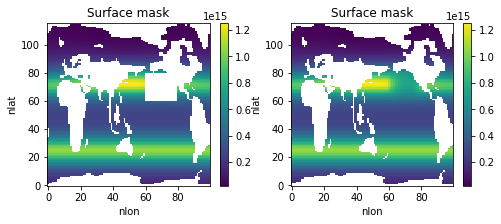

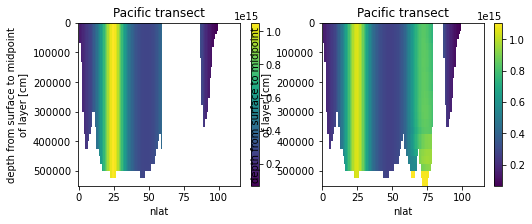

In [12]:
def fill_unmapped_points(da, grid_name):
    """fill unmapped points"""
    
    ds_grid = grids[grid_name]
    MASK_ZT = get_mask_zt(ds_grid)
    MASK_ZW = get_mask_zw(ds_grid)
    ltripole = (ds_grid.type == 'tripole')

    if 'z_t' in da.dims:
        da_fill = pop_tools.lateral_fill(da.copy(), MASK_ZT, ltripole=ltripole)
    
        # propagate values down to fill vertically, if necessary
        unfilled = da_fill.isnull() & (MASK_ZT == 1.) 
        if not unfilled.any():
            return da_fill
        nk = len(da_fill.z_t)
    else:
        da_fill = pop_tools.lateral_fill(da.copy(), MASK_ZW, ltripole=ltripole)
    
        # propagate values down to fill vertically, if necessary
        unfilled = da_fill.isnull() & (MASK_ZW == 1.) 
        nk = len(da_fill.z_w_bot)

    for k in range(1, nk):
        da_fill[k, :, :] = xr.where(
            unfilled[k, :, :], 
            da_fill[k-1, :, :], 
            da_fill[k, :, :]
        )
    return da_fill


# Check to see if it works
test_field = (get_mask_zt(grids[tst_grid]) * grids[tst_grid].TAREA).where(get_mask_zt(grids[tst_grid]) > 0)
test_field[:, 60:80, 60:80] = np.nan
test_field_fill = fill_unmapped_points(test_field, tst_grid)

fig = plt.figure(figsize=(8, 3))

ax = fig.add_subplot(1, 2, 1)
test_field.isel(z_t=0).plot()
h = plt.title('Surface mask')

ax = fig.add_subplot(1, 2, 2)
test_field_fill.isel(z_t=0).plot()
h = plt.title('Surface mask')


fig = plt.figure(figsize=(8, 3))

ax = fig.add_subplot(1, 2, 1)
test_field.isel(nlon=65).plot(yincrease=False)
h = plt.title('Pacific transect')
ax = fig.add_subplot(1, 2, 2)
test_field_fill.isel(nlon=65).plot(yincrease=False)
h = plt.title('Pacific transect')

In [13]:
def Bgrid_to_Agrid(arr_Bgrid):
    """
    Interpolates values at U points on a B grid to T points.
    """
    with xr.set_options(keep_attrs=True):
        return 0.25 * (
            arr_Bgrid +  # j, i
            arr_Bgrid.roll(nlat=1, roll_coords=False) + # j-1, i
            arr_Bgrid.roll(nlon=1, roll_coords=False) + # j, i-1
            arr_Bgrid.roll(nlat=1, nlon=1, roll_coords=False) #j-1, i-1
        )

## Get model data and generate zarr archives 

In [14]:
if not serial:
    from ncar_jobqueue import NCARCluster
    cluster = NCARCluster()
    cluster.scale(36)
    cluster

In [15]:
if not serial:
    from dask.distributed import Client
    client = Client(cluster) # Connect this local process to remote workers
    client

In [16]:
def ds_mean_time(ds, variables):
    """Compute the temporal mean of a dataset
       using weights computed from `time_bound`.
    """
    time_weights = ds.time_bound.diff('d2').squeeze()
    time_total = time_weights.sum()
    wgt = time_weights / time_total
    np.testing.assert_allclose(wgt.sum(), 1.0, rtol=1e-7)

    with xr.set_options(keep_attrs=True):
        return (ds[variables] * wgt).sum('time')

#### empty markdown?

In [17]:
dsets = dict()

grid_vars = ['TAREA', 'KMT', 'z_t'] #, 'TLONG', 'TLAT', 'ULONG', 'ULAT', 'time', 'time_bound']

def get_data_new(ds_grid, variables):
    """ Jun already computed a time-mean """
    ds = xr.open_dataset(os.path.join(os.path.sep,
                                      "glade",
                                      "work",
                                      "mlevy",
                                      "cesm_inputdata",
                                      "inputs_for_fe_forcing",
                                      "JAMES_8p4z_last20yr_annual_mean.nc")
                        )[variables]

    return xr.merge((ds, ds_grid[grid_vars]), join="override")

def get_data_old(src_grid, ds_grid, variables):
    """return a time-mean dataset"""

    if src_grid == 'POP_gx1v7':
        
        case = 'b.e21.B1850.f09_g17.CMIP6-piControl.001'
        droot = f'/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/{case}'
        droot = f'{droot}/ocn/proc/tseries/month_1'
        datestr = '060001-069912'

        ds = xr.Dataset()
        input_files = []
        for v in variables:
            files = f'{droot}/{case}.pop.h.{v}.{datestr}.nc'
            input_files += ','.join(files)+'; '
            dsv = xr.open_dataset(
                files, 
                decode_times=False,
                decode_coords=False,
                chunks={'time': 24, 'z_t': 20},
            )
            ds = xr.merge((ds, dsv))

        with util.timer('computing time mean'):
            ds = ds_mean_time(ds, variables).drop('z_t').compute()

    elif src_grid == 'POP_tx0.1v3':
       
        case = 'g.e20.G.TL319_t13.control.001_hfreq'        
        #droot = '/glade/campaign/cesm/development/omwg'        
        droot = '/glade/scratch/mclong/campaign-mirror'
        droot = f'{droot}/{case}/ocn/hist/mavg'

        years = np.arange(50, 60, 1)

        print('computing each annual mean')    
        ds_sum = xr.Dataset()
        n = 0
        input_files = []
        for y in years:
            files = sorted(glob(f'{droot}/{case}.pop.h.{y:04d}-??.nc'))        
            if len(files) != 12:
                raise ValueError('expected 12 files')                
            
            input_files.extend(files)
            
            print(f'averaging {len(files)} files')
            with util.timer(f'year: {y:04d}'):                            
                ds = xr.open_mfdataset(
                    files, 
                    combine='nested', 
                    concat_dim='time',
                    chunks={'time': 1, 'nlon': 900, 'nlat': 600},
                    decode_times=False,
                    decode_coords=False,
                )
                ds = ds_mean_time(ds, variables).drop('z_t').compute()

                if n == 0:
                    ds_sum = ds
                else:
                    ds_sum = ds_sum + ds
                n += 1

        with util.timer('computing long-term mean'):
            ds = ds_sum / n

    else:
        raise ValueError(f'unknown grid: {grid}')
        
    ds.attrs['input_files'] = ','.join(input_files)
    
    return xr.merge((ds, ds_grid[grid_vars]))

In [18]:
var_groups = dict(
    scalar=['POC_FLUX_IN', 'TEMP', 'KVMIX'],
    vector=['UVEL', 'VVEL'],
)

        
def proc_var_group_new(var_group, grids, src_grid, dst_grid=None):
    """Generate output dataset    
    """

    if dst_grid is None:
        dst_grid = src_grid

    variables = var_groups[var_group]
    key = f'{src_grid}-{var_group}'

    # get the input dataset
    if key in dsets:
        print('cached dataset')
        ds_src = dsets[key]

    else:
        print('generating dataset from files')
        ds_src = get_data_new(grids[src_grid], variables)

        # put UVEL and VVEL on T-Grid
        if var_group == 'vector':
            for v in variables:
                ds_src[v] = Bgrid_to_Agrid(ds_src[v])

        dsets[key] = ds_src

    # return dataset, performing regridding if necesssary
    if src_grid == dst_grid:
        return ds_src

    else:
        ds_dst = xr.Dataset()

        for v in variables:
            # perform lateral regridding
            key = get_key(src_grid, dst_grid)
            da_dst = regrid_operator[key](
                ds_src[v], 
                renormalize=True, 
                apply_mask=True
            ).squeeze()

            # perform vertical regridding
            if not dst_grid.startswith("MOM"):
                da_dst = util.remap_z_t(da_dst, src_grid, dst_grid)
            else:
                if v == "POC_FLUX_IN":
                    da_dst = util.reintegrate_z_t_to_MOM(da_dst, grids[src_grid])
                else:
                    dst_z_t, dst_z_w = util.get_WOA_zt_and_zw()
                    if 'z_t' in da_dst.dims:
                        da_dst = da_dst.interp(z_t=dst_z_t.data, kwargs={'fill_value': (da_dst.isel(z_t=0), da_dst.isel(z_t=-1))})
                    else:
                        da_dst = da_dst.interp(z_w_bot=dst_z_w[1:].data, kwargs={'fill_value': (da_dst.isel(z_w_bot=0), da_dst.isel(z_w_bot=-1))})

            # fill missing values left on dst_grid
            print(v)
            da_dst = fill_unmapped_points(da_dst, dst_grid)

            # copy DataArray to outgoing Dataset
            ds_dst[v] = da_dst

        return ds_dst

In [19]:
%%time

var_group_grids = dict(
    scalar=[
        ('POP_gx1v7', dst_grid), 
        # ('POP_gx1v7', 'MOM_tx0.66v1'), 
    ],
    vector=[
        ('POP_gx1v7', dst_grid), 
        # ('POP_gx1v7', 'MOM_tx0.66v1'), 
#         ('POP_tx0.1v3', 'MOM_tx0.66v1'),
    ],
)

for var_group in var_groups:
    print('-'*80)
    print(f'{var_group}: {src_grid} --> {dst_grid}')

    file_out = f'{util.dirwork}/{var_group}.{src_grid}_to_{dst_grid}_new.zarr'

    if clobber and os.path.exists(file_out):
        shutil.rmtree(file_out)

    if os.path.exists(file_out):
        print(f'existing file: {file_out}')
        dso = xr.open_zarr(file_out)
    else:
        dso = proc_var_group_new(var_group, grids, src_grid, dst_grid)
        dso["TAREA"] = grids[dst_grid]["TAREA"]
        dso = dso.assign_coords({'TLAT': grids[dst_grid].TLAT,
                                 'TLONG': grids[dst_grid].TLONG,})
        dso.to_zarr(file_out)
        dso.info()
    print()

--------------------------------------------------------------------------------
scalar: POP_gx1v7 --> MOM_tx2_3v2
existing file: /glade/work/mlevy/cesm_inputdata/work/scalar.POP_gx1v7_to_MOM_tx2_3v2_new.zarr

--------------------------------------------------------------------------------
vector: POP_gx1v7 --> MOM_tx2_3v2
existing file: /glade/work/mlevy/cesm_inputdata/work/vector.POP_gx1v7_to_MOM_tx2_3v2_new.zarr

CPU times: user 13.8 ms, sys: 0 ns, total: 13.8 ms
Wall time: 13.8 ms


In [20]:
if not serial:
    client.close()
    cluster.close()

### Some POC conservation tests

In [21]:
def compute_lateral_mean_vertical_sum_POC(ds, area):
    return (ds["POC_FLUX_IN"]*ds[area]).sum().data/1e4

In [22]:
file_in = f'{util.dirwork}/scalar.{src_grid}_to_{dst_grid}_new.zarr'
dso = xr.open_dataset(file_in, engine='zarr')
dso

<xarray.Dataset>
Dimensions:      (z_w_bot: 103, nlat: 480, nlon: 540, z_t: 103)
Coordinates:
    TLAT         (nlat, nlon) float32 ...
    TLONG        (nlat, nlon) float32 ...
    time         object ...
  * z_t          (z_t) float64 250.0 750.0 1.25e+03 ... 5.625e+05 5.875e+05
  * z_w_bot      (z_w_bot) float64 500.0 1e+03 1.5e+03 ... 5.75e+05 6e+05
Dimensions without coordinates: nlat, nlon
Data variables:
    KVMIX        (z_w_bot, nlat, nlon) float64 ...
    POC_FLUX_IN  (z_t, nlat, nlon) float64 ...
    TAREA        (nlat, nlon) float32 ...
    TEMP         (z_t, nlat, nlon) float64 ...

In [23]:
pop_POC_sum = compute_lateral_mean_vertical_sum_POC(get_data_new(grids[src_grid], ["POC_FLUX_IN"]), "TAREA")
pop_POC_sum

43395770972278.49

In [24]:
mom_POC_sum = compute_lateral_mean_vertical_sum_POC(dso, "TAREA")
mom_POC_sum

44020147966509.945

In [25]:
(pop_POC_sum - mom_POC_sum) / pop_POC_sum

-0.014387968694698598